# Crypto-Enhanced Multi-Asset Portfolio Optimization
## Notebook 01 — Walk-Forward OOS Backtest of the Constrained Minimum-Variance Baseline

*Chapter 1 — Baseline construction and out-of-sample evidence (gross of costs).*

---

### Abstract

This notebook documents and analyses the **baseline** of a constrained Minimum-Variance (MV) walk-forward, out-of-sample (OOS) backtest over a multi-asset universe (equities, bonds, gold, BTC, ETH) for the period October 2018 – May 2026. The strategy is benchmarked against three economically meaningful references — equal-weight, 60/40 (SPY/TLT), and a fixed-small-crypto allocation — under realistic long-only constraints (per-asset cap of 35%, aggregate crypto cap of 20%) and monthly rebalancing.

The contribution of this notebook is **descriptive and methodological, not inferential**: we (i) make explicit the temporal protocol that rules out look-ahead bias, (ii) report performance, drawdown, and rolling diagnostics, (iii) characterise allocation dynamics — concentration, cap activity, and the realised use of the crypto sleeve — and (iv) examine implementability through pre-trade-drifted turnover. All evaluation is **gross of transaction costs**; net-of-costs analysis and parametric robustness are deferred to Notebook 02.

### Research question (this chapter)

> Under a constrained MV specification and a strict walk-forward OOS protocol, what is the realised risk–return profile of the baseline relative to standard benchmarks, and what is the descriptive role of the crypto sleeve within this allocation?

### What this notebook claims, and what it does not

| Claims (within this OOS sample, gross of costs) | Does not claim |
|---|---|
| A reproducible baseline with an auditable temporal protocol. | Statistical superiority of MV vs benchmarks. |
| Descriptive evidence on risk reduction and drawdown control. | Stability of those properties under parametric perturbations. |
| Characterisation of weights, concentration, and cap activity. | Causal interpretation of crypto entry into MV. |
| A first read on operational load via turnover. | Net-of-cost economic viability. |

### Position in the project roadmap

The baseline established here is the prerequisite for Chapter 2 (Notebook 02), which examines robustness — sensitivity to lookback, crypto cap, rebalancing frequency, sample-vs-Ledoit-Wolf covariance, and gross-vs-net costs — and a light confirmatory layer based on preregistered block-bootstrap intervals for Sharpe differences. The next chapters (regimes, tail-risk objectives, ML overlays) are explicitly out of scope here.

> The optimisation/backtest engine lives in `src/backtest.py`, `src/optimizer.py`, `src/costs.py`, and is driven by `scripts/run_backtest.py`. This notebook **does not re-execute** the engine: it loads precomputed artefacts from `data/processed/` and analyses them.


### Literature anchors

The design choices below are informed by, and should be read against, four well-known stylised facts of portfolio research:

- **Mean-variance is fragile in inputs, not in concept.** Markowitz (1952) provides the variance-minimising framework, but Best & Grauer (1991) and Chopra & Ziemba (1993) show that small perturbations in expected returns generate large weight swings, motivating *risk-only* objectives such as Minimum Variance and the use of constraints (Jagannathan & Ma, 2003).
- **Naive diversification is a hard benchmark.** DeMiguel, Garlappi & Uppal (2009) document that 1/*N* is difficult to beat OOS once estimation error and turnover are honestly accounted for. This is the reason equal-weight is treated here as a primary benchmark, not a strawman.
- **Estimation error is the dominant source of OOS underperformance** for unconstrained MV. Ledoit & Wolf (2003, 2004) propose shrinkage covariance estimators as a partial remedy; this motivates the sample-vs-Ledoit-Wolf comparison performed in Chapter 2 (not in this notebook).
- **Crypto in portfolio construction.** Liu & Tsyvinski (2021) and Liu, Tsyvinski & Wu (2022) document that crypto returns are weakly explained by traditional factors and exhibit time-varying correlation with equities. The literature is consistent with treating crypto as a *bounded* sleeve under explicit caps rather than as a structural risk factor.

These anchors frame the methodology but do not pre-commit to results: they motivate why MV with constraints, hard benchmarks, and OOS evaluation are reasonable starting points before adding shrinkage, tail-risk objectives, or regime-conditioning.


---
## 1 — Methodology and scope

### 1.1 Strategy specification

| Component | Baseline definition |
|---|---|
| Objective | Minimise portfolio variance: $\min_{w}\; w^{\top}\Sigma w$ |
| Covariance estimator | Annualised sample covariance from daily simple returns |
| Estimation window (lookback) | 252 business days (~1 year) |
| Rebalancing | Monthly, first business day |
| Constraints | Long-only ($w_i \ge 0$); $\sum_i w_i = 1$; $w_i \le 0{.}35$; $w_{\text{BTC}} + w_{\text{ETH}} \le 0{.}20$ |
| Universe | BTC-USD, ETH-USD, SPY, QQQ, GLD, TLT |
| Benchmarks | `equal_weight`, `sixty_forty` (60% SPY / 40% TLT), `fixed_small_crypto` |
| Risk-free rate | $r_f = 0$ throughout (Sharpe is excess-return-naive but consistent across strategies) |

The use of *constraints* is itself a regularisation device: Jagannathan & Ma (2003) show that no-shorting and weight caps act as implicit shrinkage, which is consistent with the well-documented fragility of unconstrained MV (Best & Grauer, 1991). The sample covariance is intentionally chosen here as the *most exposed* estimator, so that any robustness gains in Chapter 2 (Ledoit-Wolf) can be attributed cleanly.

### 1.2 Walk-forward OOS protocol

For each rebalance date $t$:

1. Estimate $\hat{\Sigma}_t$ using only $[t-\text{lookback},\; t-1]$.
2. Solve the constrained QP for target weights $w_t^{\star}$.
3. Hold $w_t^{\star}$ from $t$ until the next rebalance, while pre-trade weights *drift* with realised returns.
4. At rebalance $t+1$, compute one-way turnover against the **pre-trade drifted** weights, not against $w_t^{\star}$:
   $$\text{TO}_{t+1} = \tfrac{1}{2}\sum_i \bigl|\,w_{t+1}^{\star}\!-\! w_{t+1}^{\text{pre}}\,\bigr|.$$

This protocol guarantees:

- No look-ahead in either covariance estimation or weight construction.
- Turnover that reflects the *actual* trades a portfolio manager would execute.
- A clean separation between estimation sample and evaluation sample, which is the *minimum* condition for OOS credibility (DeMiguel, Garlappi & Uppal, 2009).

### 1.3 Questions this notebook answers (and does not answer)

| Question (descriptive, OOS, gross) | Answered here? |
|---|---|
| What risk–return profile does the baseline produce vs benchmarks? | **Yes** (§3–§4) |
| How does the allocation evolve, and how concentrated is it? | **Yes** (§5) |
| What is the realised role of the crypto sleeve in MV? | **Yes, descriptively** (§5.1) |
| Is gross operational load plausible? | **Yes** (§6) |
| Are these properties statistically robust? | **No** — see Notebook 02 |
| Are they robust to lookback / cap / frequency / cov method? | **No** — see Notebook 02 |
| Are they robust to transaction costs? | **No** — see Notebook 02 |


### 1.4 What walk-forward OOS solves — and what it does not

A walk-forward OOS protocol is *necessary but not sufficient* for credible empirical evaluation. It is useful to be explicit about both sides.

**Solved by the protocol:**
- Strict temporal separation between estimation and evaluation.
- Elimination of mechanical look-ahead in covariance and weight construction.
- A more honest evaluation than any in-sample fit, which is known to flatter MV strongly (Michaud, 1989; "the Markowitz optimisation enigma").

**Not solved by the protocol alone:**
- *Estimation error* in the covariance matrix when sample size is comparable to the cross-section (Ledoit & Wolf, 2003).
- *Regime dependence*: the OOS realisation is still a single draw from a non-stationary process; correlations break exactly when diversification is most needed (Longin & Solnik, 2001; Ang & Bekaert, 2002).
- *Inferential* claims about strategy superiority — these require resampling-based intervals (e.g., circular block bootstrap of Politis & Romano, 1994), which are introduced in Chapter 2.
- *Economic* viability after frictions: gross-of-cost results overstate net performance, with the bias scaling in turnover (DeMiguel, Garlappi, Nogales & Uppal, 2009).

The reading rule of this notebook follows from the above: the baseline produces *evidence within an OOS sample*, not a closed-form claim of structural superiority.


---
## 2 — Data preparation and validation

The notebook consumes four core artefacts produced by `scripts/run_backtest.py` (and two optional ones for richer diagnostics):

| File | Role |
|---|---|
| `portfolio_returns.csv` | Daily OOS return panel (one column per strategy). |
| `backtest_summary.csv` | Per-strategy headline metrics (return, vol, Sharpe, MDD, Calmar). |
| `weights_history.csv` | Target weights at each rebalance date. |
| `turnover_history.csv` | Pre-trade-drifted one-way turnover and rebalance flags. |
| `returns_simple.csv` *(optional)* | Asset-level daily returns, used for §5.1 crypto-activation diagnostics. |
| `returns_log.csv` *(optional)* | Log-returns; not strictly required here. |

The validation cell below performs structural checks — column presence, monotone index, length parity between weights and turnover — to fail loudly if upstream artefacts drift. None of the analysis below proceeds if these checks fail.


In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# ── Plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# Consistent colours and styles across all sections
STYLE = {
    "min_variance":       {"lw": 2.4, "ls": "-",  "color": "#1f77b4"},
    "equal_weight":       {"lw": 1.5, "ls": "--", "color": "#ff7f0e"},
    "sixty_forty":        {"lw": 1.5, "ls": "-.", "color": "#2ca02c"},
    "fixed_small_crypto": {"lw": 1.5, "ls": ":",  "color": "#9467bd"},
}
LABELS = {
    "min_variance":       "Minimum Variance (OOS)",
    "equal_weight":       "Equal Weight (1/N)",
    "sixty_forty":        "60/40",
    "fixed_small_crypto": "Fixed Small Crypto",
}

print("Libraries loaded. PROJECT_ROOT:", PROJECT_ROOT)

Libraries loaded. PROJECT_ROOT: C:\Users\dframent\OneDrive - NTT DATA EMEAL\Desktop\ProyectosData\Multi_Asset_Portfolio_Optimization


In [12]:
def _load(filename: str, **kwargs) -> pd.DataFrame | None:
    """Load a CSV from PROCESSED_DIR with basic error handling."""
    path = PROCESSED_DIR / filename
    if not path.exists():
        print(f"  ⚠️  NOT FOUND : {path}")
        return None
    df = pd.read_csv(path, **kwargs)
    print(f"  ✅ Loaded     : {filename}  →  {df.shape[0]} rows × {df.shape[1]} cols")
    return df


print("Loading processed outputs ...\n")

portfolio_returns = _load("portfolio_returns.csv",  index_col=0, parse_dates=True)
backtest_summary  = _load("backtest_summary.csv",   index_col=0)
weights_history   = _load("weights_history.csv",    index_col=0, parse_dates=True)
turnover_history  = _load("turnover_history.csv",   index_col=0, parse_dates=True)

# Optional inputs for richer descriptive diagnostics
returns_simple = _load("returns_simple.csv", index_col=0, parse_dates=True)
returns_log    = _load("returns_log.csv",    index_col=0, parse_dates=True)

Loading processed outputs ...

  ✅ Loaded     : portfolio_returns.csv  →  2771 rows × 4 cols
  ✅ Loaded     : backtest_summary.csv  →  4 rows × 5 cols
  ✅ Loaded     : weights_history.csv  →  92 rows × 6 cols
  ✅ Loaded     : turnover_history.csv  →  92 rows × 4 cols
  ✅ Loaded     : returns_simple.csv  →  3042 rows × 6 cols
  ✅ Loaded     : returns_log.csv  →  3042 rows × 6 cols


In [13]:
# -- Structural validation ------------------------------------------------------
print("\nValidation checks:")

EXPECTED = {
    "portfolio_returns": ["min_variance", "equal_weight", "sixty_forty", "fixed_small_crypto"],
    "backtest_summary":  ["ann_return", "ann_volatility", "sharpe", "max_drawdown", "calmar"],
    "weights_history":   ["BTC-USD", "ETH-USD", "SPY", "QQQ", "GLD", "TLT"],
    "turnover_history":  ["turnover_one_way", "is_initial_rebalance"],
}

dfs = {
    "portfolio_returns": portfolio_returns,
    "backtest_summary":  backtest_summary,
    "weights_history":   weights_history,
    "turnover_history":  turnover_history,
}

all_ok = True
for name, expected_cols in EXPECTED.items():
    df = dfs[name]
    if df is None:
        print(f"  ❌ {name}: file missing -- downstream cells will fail")
        all_ok = False
        continue
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        print(f"  ⚠️  {name}: missing columns {missing}")
        all_ok = False
    else:
        print(f"  ✅ {name}: all expected columns present")

# Optional files: informative only
for name, df in {"returns_simple": returns_simple, "returns_log": returns_log}.items():
    if df is None:
        print(f"  ℹ️  {name}: not available (optional)")
    else:
        print(f"  ✅ {name}: available for extended diagnostics")

# Date range summary
if portfolio_returns is not None:
    idx = portfolio_returns.index
    assert idx.is_monotonic_increasing, "portfolio_returns index not sorted"
    print(f"\nOOS date range  : {idx[0].date()} -> {idx[-1].date()}")
    print(f"OOS trading days: {len(idx)}")

if weights_history is not None and turnover_history is not None:
    assert len(weights_history) == len(turnover_history), \
        f"Length mismatch: weights={len(weights_history)}, turnover={len(turnover_history)}"
    print(f"Rebalances      : {len(weights_history)}")

print("\n✅ Core checks passed." if all_ok else "\n⚠️  Some core checks failed -- see messages above.")


Validation checks:
  ✅ portfolio_returns: all expected columns present
  ✅ backtest_summary: all expected columns present
  ✅ weights_history: all expected columns present
  ✅ turnover_history: all expected columns present
  ✅ returns_simple: available for extended diagnostics
  ✅ returns_log: available for extended diagnostics

OOS date range  : 2018-10-01 -> 2026-05-02
OOS trading days: 2771
Rebalances      : 92

✅ Core checks passed.


---
## 3 — Headline OOS performance

Annualised summary metrics for the four strategies over the full OOS window (October 2018 – May 2026), loaded from `backtest_summary.csv`. The first table reports raw levels; the second reports differentials of each benchmark vs Minimum Variance, in percentage points (pp) for return/vol/MDD and in raw units for Sharpe — to make the trade-off explicit.


In [4]:
DISPLAY_COLS = {
    "ann_return":     "Ann. Return",
    "ann_volatility": "Ann. Volatility",
    "sharpe":         "Sharpe Ratio",
    "max_drawdown":   "Max Drawdown",
    "calmar":         "Calmar Ratio",
}
STRATEGY_ORDER = ["min_variance", "equal_weight", "sixty_forty", "fixed_small_crypto"]

summary_tbl = backtest_summary.reindex(STRATEGY_ORDER)[list(DISPLAY_COLS)].copy()
summary_tbl.index = [LABELS.get(s, s) for s in summary_tbl.index]
summary_tbl.columns = list(DISPLAY_COLS.values())

fmt = summary_tbl.copy().astype(object)
for col in ["Ann. Return", "Ann. Volatility", "Max Drawdown"]:
    fmt[col] = summary_tbl[col].map(lambda x: f"{x*100:+.2f}%")
for col in ["Sharpe Ratio", "Calmar Ratio"]:
    fmt[col] = summary_tbl[col].map(lambda x: f"{x:.3f}")

fmt

,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown,Calmar Ratio
Minimum Variance (OOS),+8.32%,+8.94%,0.930,-23.33%,0.356
Equal Weight (1/N),+18.74%,+22.31%,0.840,-45.33%,0.413
60/40,+6.01%,+10.48%,0.574,-27.24%,0.221
Fixed Small Crypto,+12.47%,+12.52%,0.996,-30.41%,0.410


In [14]:
# Quantified differentials versus Minimum Variance (MV)
base = backtest_summary.loc["min_variance"]
bench = backtest_summary.loc[["equal_weight", "sixty_forty", "fixed_small_crypto"]].copy()

performance_deltas = pd.DataFrame({
    "return_gap_pp (benchmark - MV)": (bench["ann_return"] - base["ann_return"]) * 100,
    "vol_gap_pp (benchmark - MV)": (bench["ann_volatility"] - base["ann_volatility"]) * 100,
    "vol_reduction_vs_benchmark_%": (1 - base["ann_volatility"] / bench["ann_volatility"]) * 100,
    "mdd_gap_pp (benchmark - MV)": (bench["max_drawdown"] - base["max_drawdown"]) * 100,
    "sharpe_gap (benchmark - MV)": bench["sharpe"] - base["sharpe"],
})

performance_deltas = performance_deltas.round(3)
performance_deltas.index.name = "benchmark"
performance_deltas

,return_gap_pp (benchmark - MV),vol_gap_pp (benchmark - MV),vol_reduction_vs_benchmark_%,mdd_gap_pp (benchmark - MV),sharpe_gap (benchmark - MV)
benchmark,,,,,
equal_weight,10.426,13.365,59.916,-22.001,-0.090
sixty_forty,-2.305,1.539,14.681,-3.903,-0.357
fixed_small_crypto,4.151,3.577,28.574,-7.078,0.066


### Reading

**Question.** What trade-off does Minimum Variance produce relative to the three benchmarks, in this OOS sample?

**Evidence (levels + differentials).**
- vs **Equal Weight**: MV gives up ~10.4 pp of annual return (8.32% vs 18.74%) but cuts annualised volatility by ~13.4 pp (8.94% vs 22.31%) — a *relative* volatility reduction of ~60% — and improves max drawdown by ~22.0 pp (−23.3% vs −45.3%).
- vs **60/40**: MV adds ~+2.3 pp of annual return *and* trims ~1.5 pp of vol; Sharpe rises by ~+0.36 (0.93 vs 0.57).
- vs **Fixed Small Crypto**: MV is ~−4.2 pp in return and ~−0.07 in Sharpe, but with ~3.6 pp lower vol and a max drawdown that is ~6.8 pp shallower.

**Interpretation.** The baseline does not maximise return; it delivers *defensive efficiency*. It systematically compresses dispersion and left-tail severity. The Sharpe edge over 60/40 and the proximity to Fixed Small Crypto suggest that the return give-up does not translate into a worse risk-adjusted profile — at least not in this realisation.

**Inferential limit.** These are point estimates from a single OOS path, gross of costs, with no formal inference. The DeMiguel–Garlappi–Uppal (2009) caveat applies: a Sharpe gap of this size *can* lie within bootstrap uncertainty for moderate samples, which is exactly the question Notebook 02 takes up. Read this section as a *cartography* of the risk–return surface, not as a verdict.


---
## 4 — Equity curves and drawdowns

Equity curves index each strategy to $100 at OOS start; drawdowns are computed as $\text{DD}_t = W_t/\max_{s\le t} W_s - 1$. Two stylised regime markers are annotated — the COVID shock (Q1-2020) and the 2022 rate-hike cycle — to anchor the reader, not to argue causation.


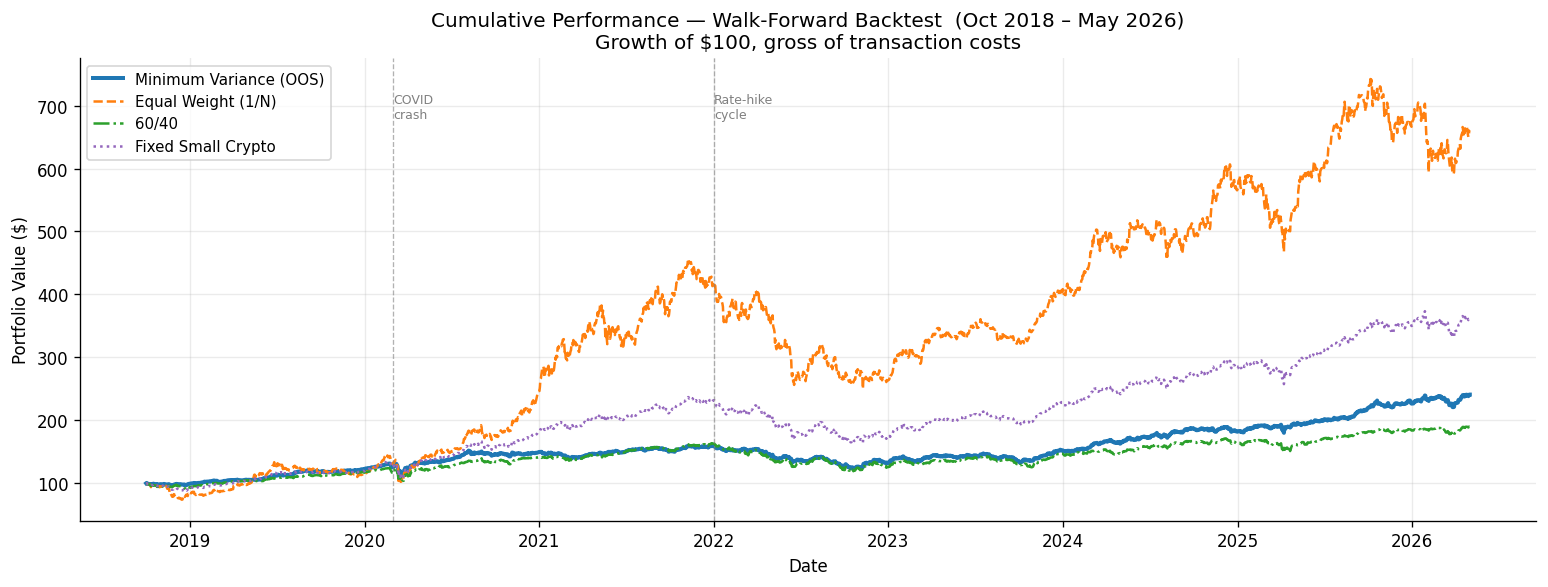

In [5]:
# ── Equity curves — indexed to 100 at OOS start ───────────────────────────────
cumulative = (1 + portfolio_returns).cumprod() * 100

fig, ax = plt.subplots(figsize=(13, 5))

for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(cumulative.index, cumulative[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])

# Mark key events
for year, label in [(2020.2, "COVID\ncrash"), (2022.0, "Rate-hike\ncycle")]:
    ts = pd.Timestamp(f"{int(year)}-{int((year % 1)*12)+1:02d}-01")
    ax.axvline(ts, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.text(ts, cumulative.max().max() * 0.97, label, fontsize=7.5,
            color="grey", ha="left", va="top")

ax.set_title("Cumulative Performance — Walk-Forward Backtest  (Oct 2018 – May 2026)\n"
             "Growth of $100, gross of transaction costs", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()

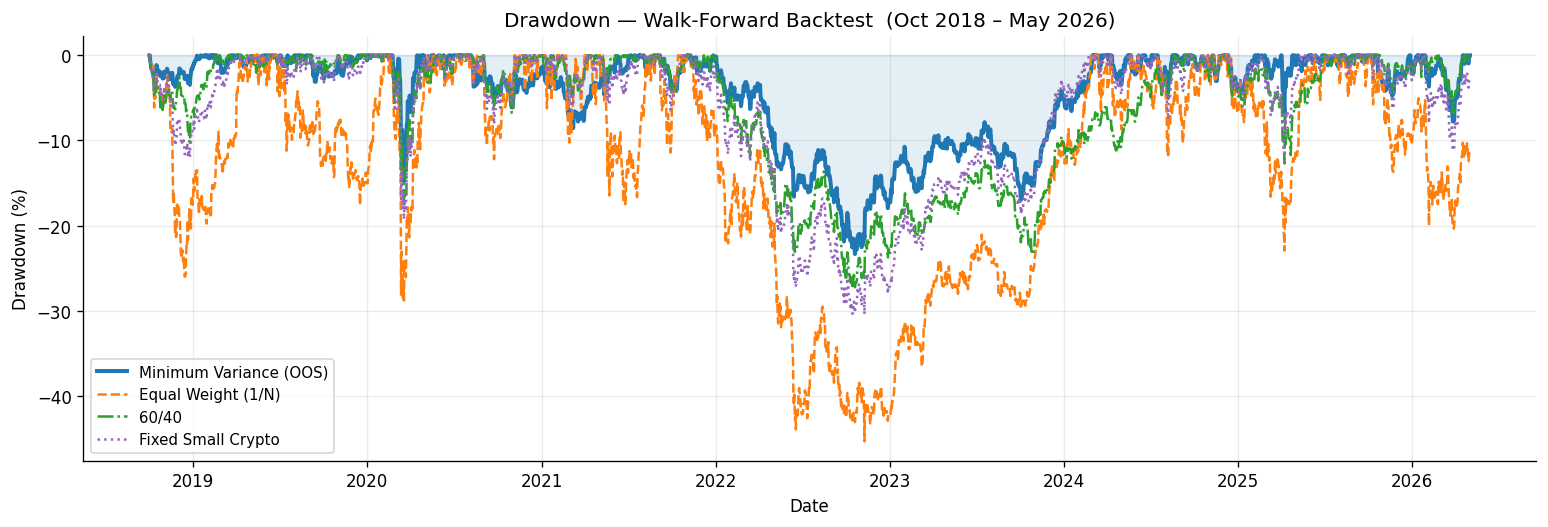

In [6]:
# ── Drawdown series ───────────────────────────────────────────────────────────
def _drawdown(returns: pd.Series) -> pd.Series:
    wealth = (1 + returns).cumprod()
    return (wealth / wealth.cummax() - 1.0) * 100   # expressed in %

drawdowns = portfolio_returns.apply(_drawdown)

fig, ax = plt.subplots(figsize=(13, 4.5))

for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(drawdowns.index, drawdowns[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])

ax.fill_between(drawdowns.index, drawdowns["min_variance"], 0,
                alpha=0.12, color=STYLE["min_variance"]["color"])

ax.set_title("Drawdown — Walk-Forward Backtest  (Oct 2018 – May 2026)", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()

### Reading

**Equity dynamics.** Cross-strategy dispersion is overwhelmingly concentrated in the 2020–2021 crypto bull cycle: Equal Weight and Fixed Small Crypto capture that regime mechanically, MV and 60/40 do not. After 2022 the ordering compresses, with MV recovering on a smaller capital loss and Equal Weight retaining higher upside convexity but from a more impaired base.

**Drawdowns.** The MV drawdown envelope is uniformly the tightest. The deepest MV episode (~−23%, 2022–2023) coincides with a regime in which both equity and duration risk premia compressed simultaneously — the textbook scenario in which long-only diversification across SPY/QQQ/TLT/GLD is structurally limited. The Equal Weight trough (~−45%) is consistent with the well-documented left-tail behaviour of unconstrained crypto exposure (Liu & Tsyvinski, 2021). 60/40 spends an unusually long time underwater in 2022–2023, illustrating the regime-dependent fragility of stock–bond correlation (Longin & Solnik, 2001; Ang & Bekaert, 2002).

**Inferential limit.** Drawdown shapes are *path-dependent and sample-specific*. They are useful to characterise the realised tail behaviour of each strategy but cannot, on their own, identify a structural ranking — e.g., the 2022 stock–bond correlation episode is a non-recurring stress event in this sample.


### 4.1 Rolling diagnostics

Headline metrics summarise a path; rolling windows tell us whether the properties are *episodic* or *persistent*. We use a 126-day window (~6 months): short enough to register regime changes, long enough to dampen high-frequency noise. Volatility and return are reported annualised. Rolling Sharpe is computed as ratio of those two; following standard practice, it should be read directionally — its sampling distribution is wide and heavy-tailed (Lo, 2002).


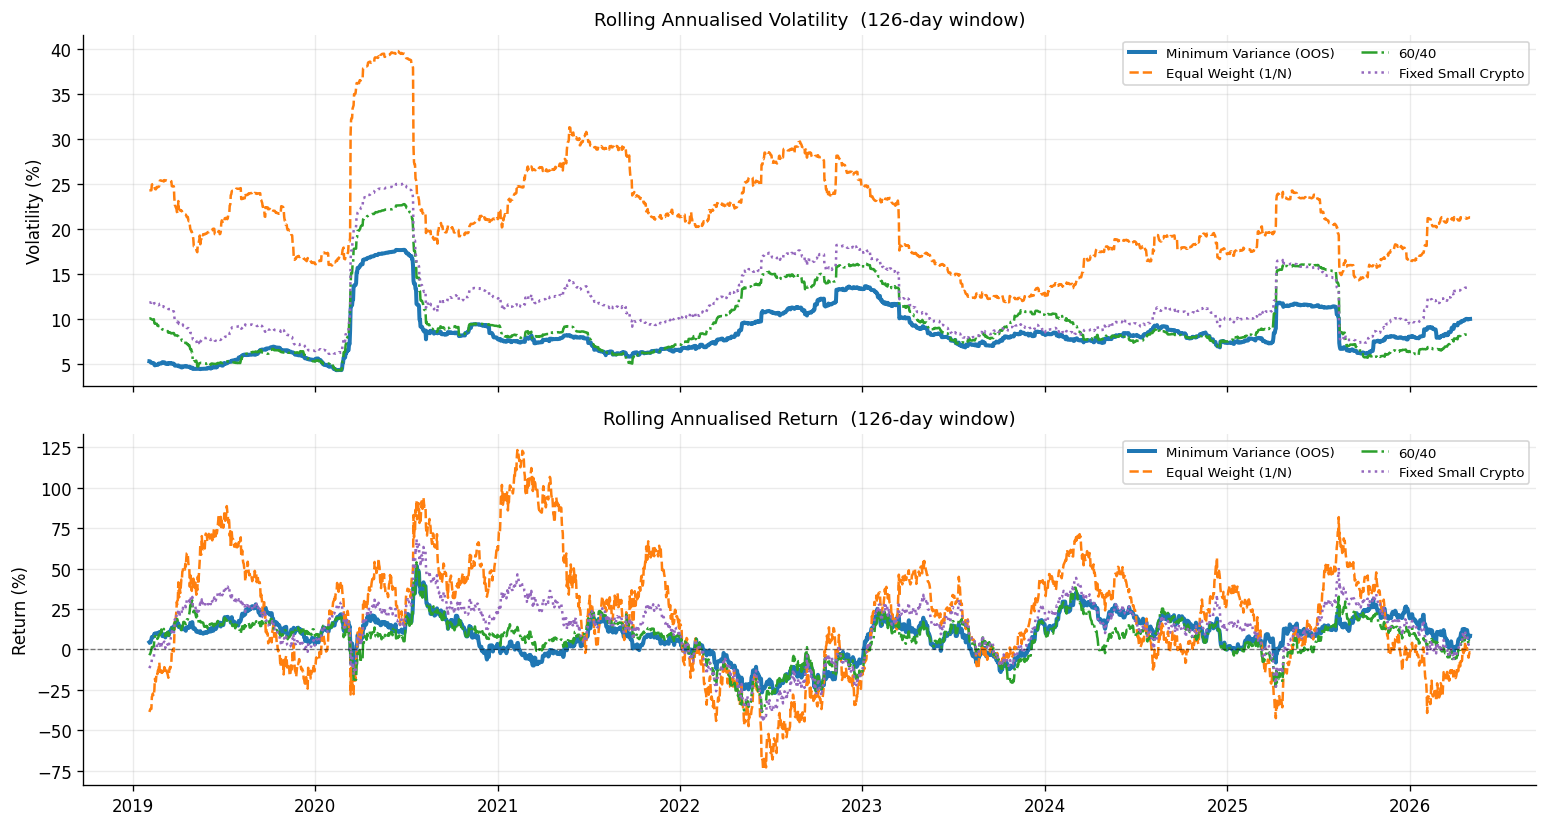

In [7]:
ROLL_WIN = 126  # ~6 months — documented window choice

roll_vol = portfolio_returns.rolling(ROLL_WIN).std() * np.sqrt(252) * 100   # annualised %
roll_ret = portfolio_returns.rolling(ROLL_WIN).mean() * 252 * 100           # annualised %

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# ── Rolling volatility ────────────────────────────────────────────────────────
ax = axes[0]
for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(roll_vol.index, roll_vol[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])
ax.set_title(f"Rolling Annualised Volatility  ({ROLL_WIN}-day window)", fontsize=11)
ax.set_ylabel("Volatility (%)")
ax.legend(loc="upper right", fontsize=8, ncol=2)

# ── Rolling return ────────────────────────────────────────────────────────────
ax = axes[1]
for col in STRATEGY_ORDER:
    s = STYLE[col]
    ax.plot(roll_ret.index, roll_ret[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"])
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_title(f"Rolling Annualised Return  ({ROLL_WIN}-day window)", fontsize=11)
ax.set_ylabel("Return (%)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())

fig.tight_layout()
plt.show()

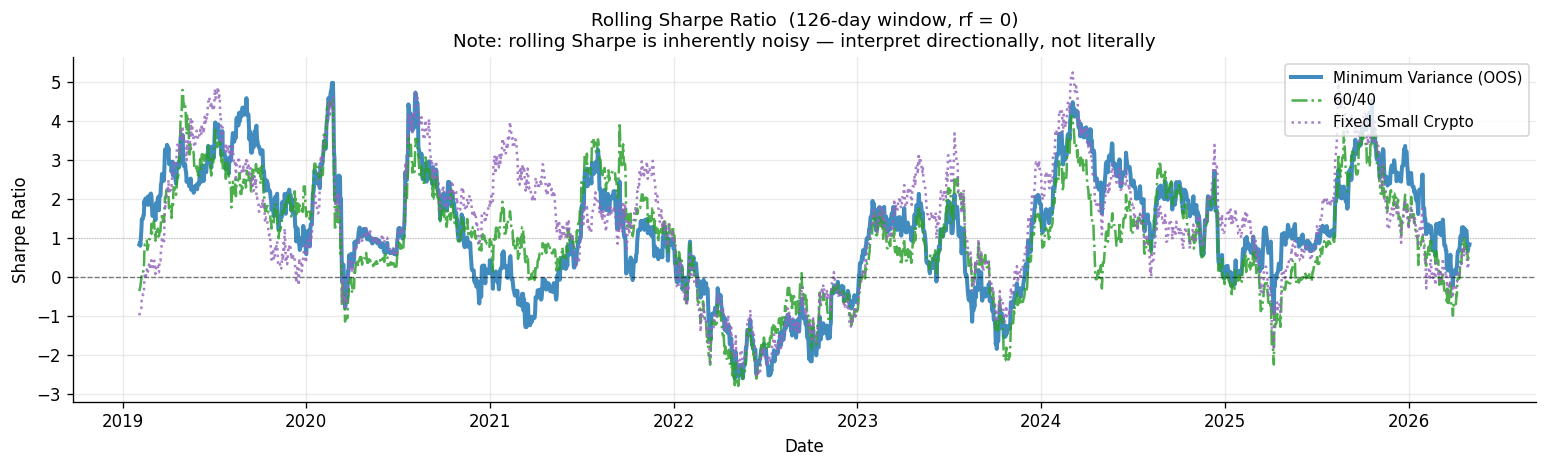

In [8]:
# ── Rolling Sharpe ────────────────────────────────────────────────────────────
# Defined as (rolling annualised return) / (rolling annualised vol).
# Note: with rf = 0 throughout. Shown only for min_variance, sixty_forty, and
# fixed_small_crypto — equal_weight is excluded because its extreme vol swings
# make the Sharpe line erratic and visually dominant without adding clarity.

roll_sharpe = (roll_ret / roll_vol).dropna(how="all")

SHARPE_COLS = ["min_variance", "sixty_forty", "fixed_small_crypto"]

fig, ax = plt.subplots(figsize=(13, 4))

for col in SHARPE_COLS:
    s = STYLE[col]
    ax.plot(roll_sharpe.index, roll_sharpe[col],
            label=LABELS[col], lw=s["lw"], ls=s["ls"], color=s["color"], alpha=0.85)

ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.axhline(1, color="grey",  lw=0.6, ls=":",  alpha=0.5)

ax.set_title(f"Rolling Sharpe Ratio  ({ROLL_WIN}-day window, rf = 0)\n"
             "Note: rolling Sharpe is inherently noisy — interpret directionally, not literally",
             fontsize=11)
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Date")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig.tight_layout()
plt.show()

In [15]:
# Rolling evidence summary (diagnostic, not inferential)
valid_roll_vol = roll_vol.dropna()
valid_roll_sharpe = roll_sharpe.dropna()

lowest_vol_share = {
    c: (valid_roll_vol.idxmin(axis=1) == c).mean() * 100 for c in valid_roll_vol.columns
}
positive_sharpe_share = {
    c: (valid_roll_sharpe[c] > 0).mean() * 100 for c in SHARPE_COLS
}

rolling_evidence = pd.DataFrame({
    "share_lowest_rolling_vol_%": pd.Series(lowest_vol_share),
    "share_positive_rolling_sharpe_%": pd.Series(positive_sharpe_share),
}).round(2)

rolling_evidence

,share_lowest_rolling_vol_%,share_positive_rolling_sharpe_%
equal_weight,0.00,NaN
fixed_small_crypto,0.00,81.18
min_variance,75.43,77.48
sixty_forty,24.57,76.57


### Reading rolling diagnostics

**Question.** Are the defensive properties episodic or persistent across the OOS sample?

**Evidence.**
- MV records the *lowest* rolling annualised volatility in ~75% of valid windows; 60/40 captures most of the remainder (~25%). Equal Weight and Fixed Small Crypto rarely lead on volatility.
- Rolling Sharpe is positive in ~77% of windows for MV, ~77% for 60/40, and ~81% for Fixed Small Crypto.

**Interpretation.** The defensive profile is *persistent*, not concentrated in one or two episodes. The slightly higher share of positive rolling Sharpe for Fixed Small Crypto reflects path-dependent exposure to the 2020–2021 cycle and is paired with a much wider distribution and deeper drawdowns in 2022 (visible in §4).

**Inferential limit.** "Share-of-windows-leading" statistics are useful descriptive frequencies but are *not* hypothesis tests: rolling Sharpe windows are correlated, sampling variability is large (Lo, 2002), and the count is conditional on a single overlap structure. Treat these as diagnostics consistent with the equity-curve picture, not as evidence of structural superiority.


---
## 5 — Allocation dynamics: weights, concentration, cap activity

This section opens the box: how the optimiser deploys capital, how concentrated the resulting allocation is, and how often the constraints bind. Constraint activity is informative *per se* — Jagannathan & Ma (2003) show that binding caps act as implicit shrinkage and explain a non-trivial part of MV's OOS performance.

**Definitions.**
- **Active asset:** weight $> 0.5\%$ ($\theta_{\text{active}} = 0.005$).
- **Cap hit:** weight within 0.5 pp of the per-asset cap (35%) or aggregate crypto cap (20%).
- **Concentration:** Herfindahl index $\text{HHI}_t = \sum_i w_{i,t}^2$ and effective number of bets $\text{ENB}_t = 1/\text{HHI}_t$ (Bouchaud, Potters & Aguilar, 1997).

The reading rule: low ENB does not mechanically imply *risk* concentration (true risk concentration would be measured via marginal contributions to variance, which require per-rebalance covariance state and is therefore deferred). HHI/ENB is a *weight-space* diagnostic.


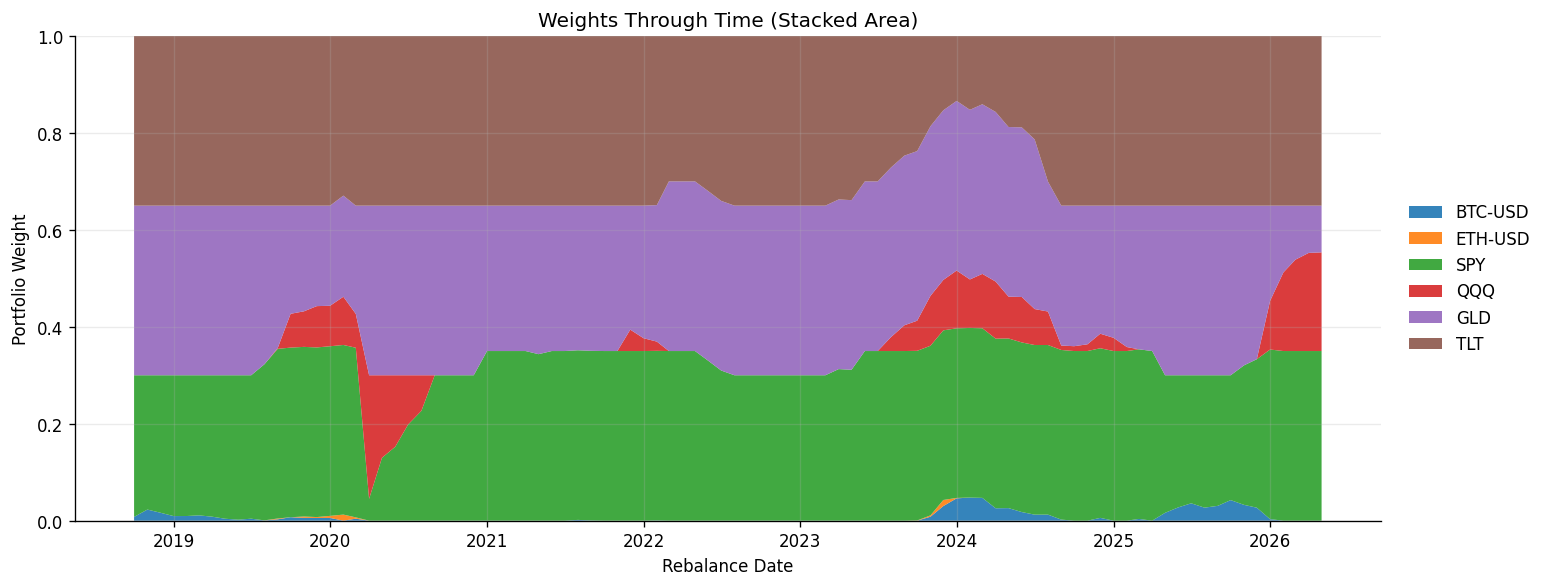

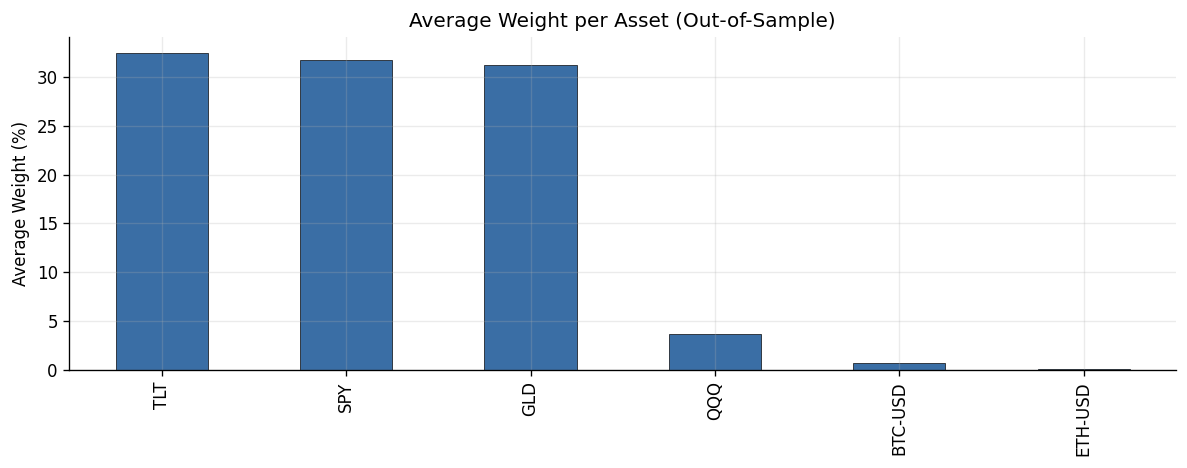

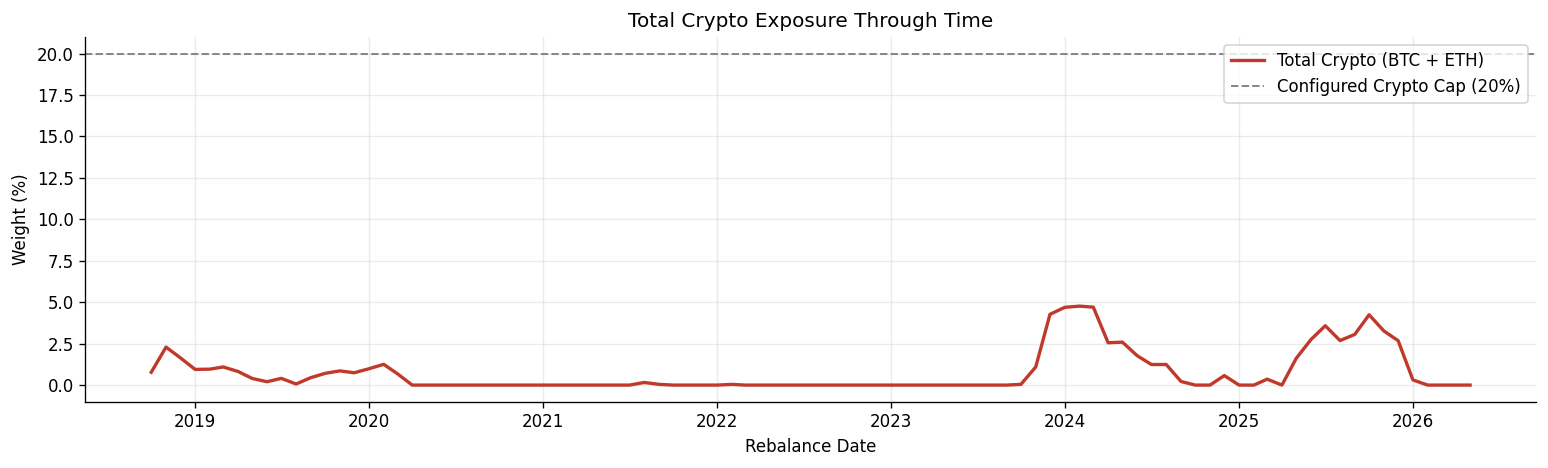

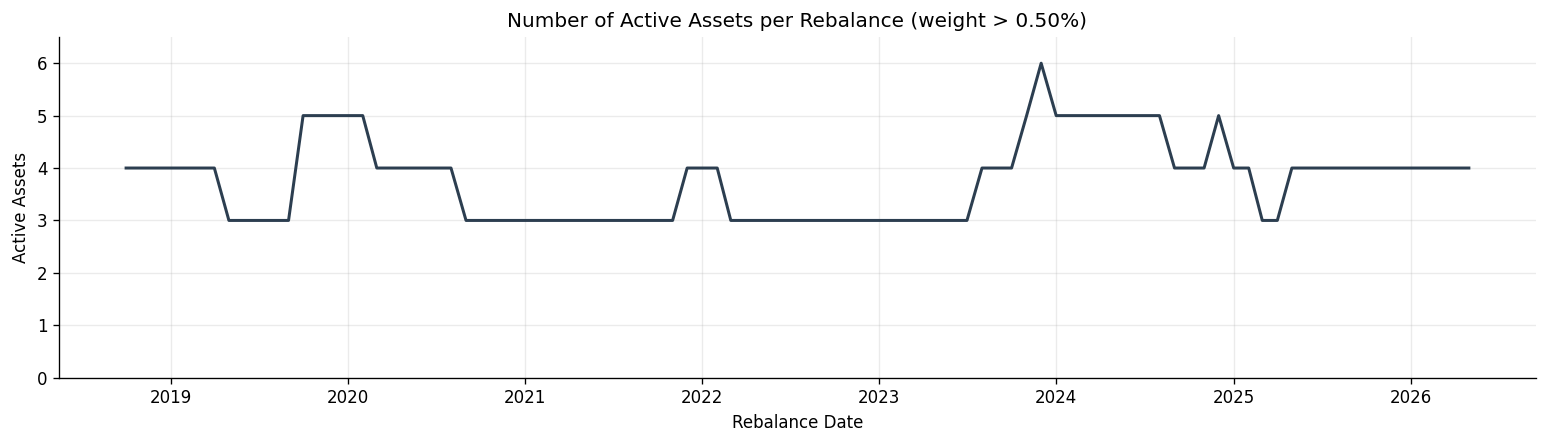

Cap-hit frequency by asset (near/touching max_weight_per_asset):


,cap_hits_count,cap_hits_pct
TLT,69,75.00
GLD,54,58.70
SPY,51,55.43
BTC-USD,0,0.00
ETH-USD,0,0.00
QQQ,0,0.00


Crypto total cap near-hits (BTC+ETH >= 19.5%): 0/92 rebalances (0.00%)


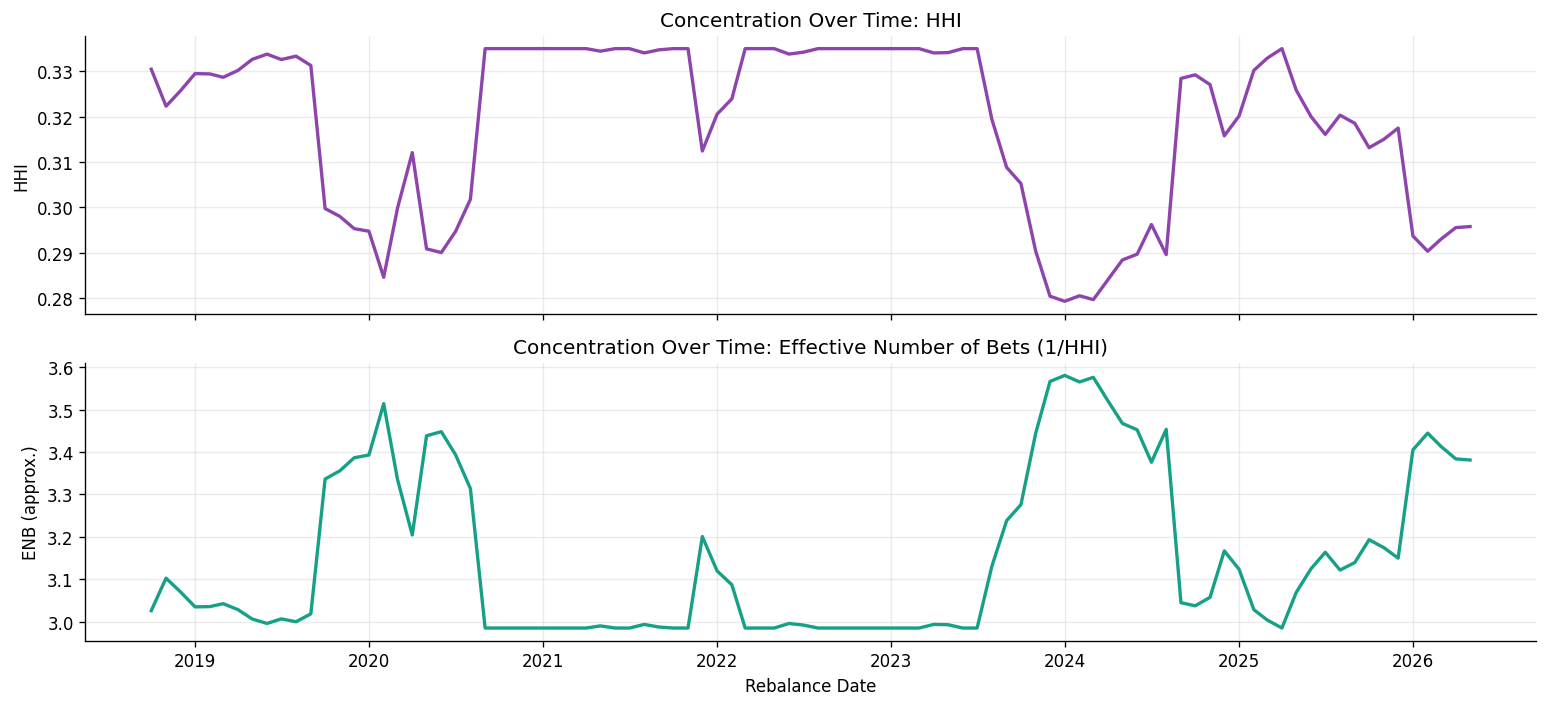

Concentration summary statistics:


,mean,std,min,25%,50%,75%,max
HHI,0.318664,0.018623,0.279258,0.299781,0.328553,0.335000,0.335000
ENB_approx,3.149260,0.193226,2.985075,2.985075,3.043652,3.335763,3.580923


Crypto exposure summary (%):


,value
crypto_mean_%,0.759
crypto_median_%,0.000
crypto_max_%,4.763
share_rebalances_crypto_gt_5%,0.000
share_rebalances_crypto_gt_10%,0.000


Active assets summary:


,value
active_assets_mean,3.761
active_assets_median,4.000
active_assets_min,3.000
active_assets_max,6.000


In [16]:
# ---- Section 5A-F: weights diagnostics --------------------------------------

ASSET_CAP = 0.35
CRYPTO_TOTAL_CAP = 0.20
ACTIVE_THRESHOLD = 0.005   # 0.5%
CAP_EPS = 0.005            # within 0.5pp of the cap is treated as "near cap"

w = weights_history.copy().sort_index()

# Keep plotting order aligned with weight columns
weight_cols = [c for c in STRATEGY_ORDER if c in w.columns]
if len(weight_cols) != len(w.columns):
    weight_cols = list(w.columns)

# A) Time evolution of weights (stacked area)
fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    w.index,
    *[w[c].values for c in weight_cols],
    labels=weight_cols,
    alpha=0.9
)
ax.set_title("Weights Through Time (Stacked Area)", fontsize=12)
ax.set_ylabel("Portfolio Weight")
ax.set_xlabel("Rebalance Date")
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
plt.show()

# B) Average weight per asset
mean_w = w.mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 4))
mean_w.plot(kind="bar", ax=ax, color="#3A6EA5", edgecolor="black", linewidth=0.4)
ax.set_title("Average Weight per Asset (Out-of-Sample)", fontsize=12)
ax.set_ylabel("Average Weight (%)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

# C) Total crypto exposure over time
crypto_cols = [c for c in ["BTC-USD", "ETH-USD"] if c in w.columns]
crypto_exposure = w[crypto_cols].sum(axis=1) if crypto_cols else pd.Series(index=w.index, dtype=float)

fig, ax = plt.subplots(figsize=(13, 4))
if len(crypto_cols):
    ax.plot(crypto_exposure.index, crypto_exposure.values * 100,
            color="#C0392B", lw=2.0, label="Total Crypto (BTC + ETH)")
    ax.axhline(CRYPTO_TOTAL_CAP * 100, color="#7F8C8D", ls="--", lw=1.2,
               label=f"Configured Crypto Cap ({CRYPTO_TOTAL_CAP:.0%})")
ax.set_title("Total Crypto Exposure Through Time", fontsize=12)
ax.set_ylabel("Weight (%)")
ax.set_xlabel("Rebalance Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
if len(crypto_cols):
    ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# D) Number of active assets per rebalance
n_active_assets = (w > ACTIVE_THRESHOLD).sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.plot(n_active_assets.index, n_active_assets.values, color="#2C3E50", lw=1.8)
ax.set_title(f"Number of Active Assets per Rebalance (weight > {ACTIVE_THRESHOLD:.2%})", fontsize=12)
ax.set_ylabel("Active Assets")
ax.set_xlabel("Rebalance Date")
ax.set_ylim(0, len(w.columns) + 0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

# E) Cap-hit frequency (per asset + crypto total)
asset_cap_hits = (w >= (ASSET_CAP - CAP_EPS)).sum().sort_values(ascending=False)
asset_cap_hits_pct = (asset_cap_hits / len(w) * 100).round(2)

cap_hits_tbl = pd.DataFrame({
    "cap_hits_count": asset_cap_hits,
    "cap_hits_pct": asset_cap_hits_pct,
}).astype({"cap_hits_count": int})

if len(crypto_cols):
    crypto_cap_hits_count = int((crypto_exposure >= (CRYPTO_TOTAL_CAP - CAP_EPS)).sum())
    crypto_cap_hits_pct = round(crypto_cap_hits_count / len(w) * 100, 2)
else:
    crypto_cap_hits_count = 0
    crypto_cap_hits_pct = 0.0

print("Cap-hit frequency by asset (near/touching max_weight_per_asset):")
display(cap_hits_tbl)
if len(crypto_cols):
    print(
        f"Crypto total cap near-hits (BTC+ETH >= {CRYPTO_TOTAL_CAP - CAP_EPS:.1%}): "
        f"{crypto_cap_hits_count}/{len(w)} rebalances ({crypto_cap_hits_pct:.2f}%)"
    )

# F) Concentration: HHI and effective number of bets
hhi = (w ** 2).sum(axis=1)
enb = 1.0 / hhi

concentration = pd.DataFrame({
    "HHI": hhi,
    "ENB_approx": enb,
})

concentration_summary = concentration.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(concentration.index, concentration["HHI"], color="#8E44AD", lw=2)
axes[0].set_title("Concentration Over Time: HHI", fontsize=12)
axes[0].set_ylabel("HHI")
axes[0].grid(alpha=0.25)

axes[1].plot(concentration.index, concentration["ENB_approx"], color="#16A085", lw=2)
axes[1].set_title("Concentration Over Time: Effective Number of Bets (1/HHI)", fontsize=12)
axes[1].set_ylabel("ENB (approx.)")
axes[1].set_xlabel("Rebalance Date")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

# Quantified summaries for interpretation
if len(crypto_cols):
    crypto_summary = pd.Series({
        "crypto_mean_%": crypto_exposure.mean() * 100,
        "crypto_median_%": crypto_exposure.median() * 100,
        "crypto_max_%": crypto_exposure.max() * 100,
        "share_rebalances_crypto_gt_5%": (crypto_exposure > 0.05).mean() * 100,
        "share_rebalances_crypto_gt_10%": (crypto_exposure > 0.10).mean() * 100,
    }).round(3)
else:
    crypto_summary = pd.Series(dtype=float)

active_assets_summary = pd.Series({
    "active_assets_mean": n_active_assets.mean(),
    "active_assets_median": n_active_assets.median(),
    "active_assets_min": n_active_assets.min(),
    "active_assets_max": n_active_assets.max(),
}).round(3)

print("Concentration summary statistics:")
display(concentration_summary)
print("Crypto exposure summary (%):")
display(crypto_summary.to_frame("value"))
print("Active assets summary:")
display(active_assets_summary.to_frame("value"))

# Expose section-level artifacts for later narrative / Section 6 relationships
weights_section_artifacts = {
    "mean_weights_pct": mean_w,
    "n_active_assets": n_active_assets,
    "cap_hits_table": cap_hits_tbl,
    "crypto_cap_hits_count": crypto_cap_hits_count,
    "crypto_cap_hits_pct": crypto_cap_hits_pct,
    "concentration": concentration,
    "concentration_summary": concentration_summary,
    "crypto_exposure": crypto_exposure,
    "crypto_summary": crypto_summary,
    "active_assets_summary": active_assets_summary,
    "active_threshold": ACTIVE_THRESHOLD,
    "asset_cap": ASSET_CAP,
    "crypto_total_cap": CRYPTO_TOTAL_CAP,
    "cap_eps": CAP_EPS,
}

### Reading allocation dynamics

**Q1 — Does MV actually use crypto?**
- *Evidence.* Mean aggregate crypto weight ≈ 0.76%, median 0.0%, max ~4.8%. Frequency above 5% is 0%; above 10% is 0%.
- *Reading.* The crypto sleeve is *available* (cap = 20%) but *barely used* by sample-MV in this OOS realisation. The 20% cap is non-binding throughout.
- *Limit.* "Marginal use" is not the same as "no contribution": even small allocations can move covariance-driven optima locally. This is the structural reason the No-Crypto control exists in Notebook 02.

**Q2 — Diversified or concentrated?**
- *Evidence.* Mean HHI ≈ 0.32, mean ENB ≈ 3.15 over a 6-asset universe; active assets per rebalance: mean 3.76 (range 3–6).
- *Reading.* *Partial* diversification with moderate concentration — exactly the typology produced by constrained MV when caps are active (Jagannathan & Ma, 2003).
- *Limit.* Weight concentration ≠ risk concentration; the latter would require marginal-contribution-to-variance, out of scope here.

**Q3 — Which assets dominate, and are corner solutions present?**
- *Evidence.* Dominant mean weights in TLT (~32.3%), SPY (~31.6%), GLD (~31.1%); cap-hit frequency: TLT 75.0%, GLD 58.7%, SPY 55.4%.
- *Reading.* Defensive / traditional assets structure the core; the per-asset caps are *economically* active, which is the regularisation channel in Jagannathan & Ma (2003).
- *Limit.* A binding cap is not a model error — it is the optimum within the feasible set defined by the manager.

**Q4 — Are weights stable or erratic?**
- *Evidence.* The stacked-area plot shows block-wise stability; the active-assets count varies in a narrow band.
- *Reading.* Stable structure with discrete adjustments at regime turning points, consistent with constrained MV under a 1-year lookback.
- *Limit.* Observational stability ≠ formal stability; bootstrap-based weight stability would be needed for inference.


### 5.1 — Why does crypto enter Minimum Variance?

The optimiser does not see returns directly; it sees the *recent* covariance matrix. The crypto sleeve enters MV when the trailing window perceives a combination of (i) volatility that is high but not catastrophic relative to peers, and (ii) correlations with traditional assets that are low enough for crypto to participate in the variance-minimising weighted combination.

This subsection is purely **descriptive**. It compares trailing return / volatility / correlation conditions in the rebalance dates where crypto receives a *material* allocation versus those where it does not. We explicitly do **not** estimate a structural model: there is no sample-splitting validation of the conditions, no causal identification, and the comparison is conditional on the realised path of constraints and prices.


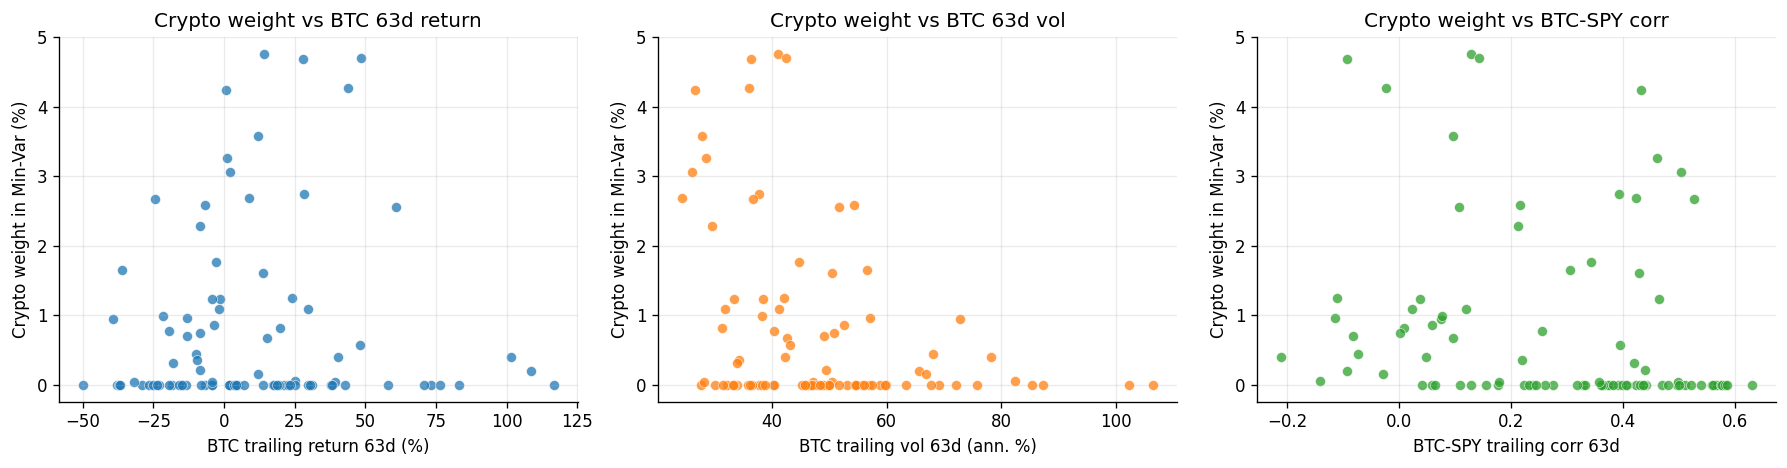

[Info] No observations above 5%; using adaptive material threshold = 2.00%.
Average trailing conditions by crypto-activation regime:


,btc_ret_63,btc_ret_126,btc_vol_63,btc_vol_126,btc_spy_corr_63,btc_tlt_corr_63,eth_ret_63,eth_vol_63
crypto_material,14.899,30.793,35.667,36.201,0.251,-0.037,20.027,57.108
crypto_near_zero,9.963,25.241,51.785,52.543,0.298,0.005,12.150,67.131


Top rebalance dates by crypto allocation (diagnostic):


,crypto_weight,btc_ret_63,btc_vol_63,btc_spy_corr_63
rebalance_date,,,,
2024-02-01,4.763,14.221,41.036,0.129
2024-03-01,4.702,48.317,42.541,0.142
2024-01-01,4.692,28.012,36.332,-0.093
2023-12-01,4.269,43.762,36.096,-0.024
2025-10-01,4.243,0.694,26.556,0.431
2025-07-01,3.582,12.105,27.904,0.096
2025-11-01,3.266,1.154,28.545,0.460
2025-09-01,3.059,1.974,26.045,0.503
2025-06-01,2.747,28.321,37.785,0.391


Activation sample summary:


,value
n_rebalances_used,92.000
material_threshold_used_%,2.000
n_material_crypto,14.000
share_material_crypto,15.217
n_near_zero_crypto_<=1%,70.000


In [19]:
# Descriptive diagnostics of crypto activation at rebalance dates
if returns_simple is None:
    print("returns_simple.csv no disponible: se omite diagnóstico de activación cripto por condiciones trailing.")
    crypto_activation = None
else:
    required_cols = ["BTC-USD", "ETH-USD", "SPY", "TLT"]
    missing_cols = [c for c in required_cols if c not in returns_simple.columns]

    if missing_cols:
        print(f"returns_simple disponible pero faltan columnas {missing_cols}; diagnóstico limitado.")
        crypto_activation = None
    else:
        rs = returns_simple.sort_index().copy()
        rb_idx = weights_history.index

        def trailing_return(series: pd.Series, window: int) -> pd.Series:
            return (1 + series).rolling(window).apply(np.prod, raw=True) - 1

        feat = pd.DataFrame(index=rs.index)
        feat["btc_ret_63"] = trailing_return(rs["BTC-USD"], 63)
        feat["btc_ret_126"] = trailing_return(rs["BTC-USD"], 126)
        feat["btc_vol_63"] = rs["BTC-USD"].rolling(63).std() * np.sqrt(252)
        feat["btc_vol_126"] = rs["BTC-USD"].rolling(126).std() * np.sqrt(252)
        feat["btc_spy_corr_63"] = rs["BTC-USD"].rolling(63).corr(rs["SPY"])
        feat["btc_tlt_corr_63"] = rs["BTC-USD"].rolling(63).corr(rs["TLT"])
        feat["eth_ret_63"] = trailing_return(rs["ETH-USD"], 63)
        feat["eth_vol_63"] = rs["ETH-USD"].rolling(63).std() * np.sqrt(252)

        crypto_total = weights_history[[c for c in ["BTC-USD", "ETH-USD"] if c in weights_history.columns]].sum(axis=1)

        crypto_activation = pd.DataFrame(index=rb_idx)
        crypto_activation["crypto_weight"] = crypto_total
        crypto_activation = crypto_activation.join(feat.reindex(rb_idx), how="left").dropna()

        if crypto_activation.empty:
            print("No hay intersección suficiente entre fechas de rebalance y features trailing.")
        else:
            fig, axes = plt.subplots(1, 3, figsize=(15, 4))

            axes[0].scatter(crypto_activation["btc_ret_63"] * 100,
                            crypto_activation["crypto_weight"] * 100,
                            alpha=0.75, color="#1F77B4", edgecolor="white", linewidth=0.4)
            axes[0].set_xlabel("BTC trailing return 63d (%)")
            axes[0].set_ylabel("Crypto weight in Min-Var (%)")
            axes[0].set_title("Crypto weight vs BTC 63d return")
            axes[0].grid(alpha=0.25)

            axes[1].scatter(crypto_activation["btc_vol_63"] * 100,
                            crypto_activation["crypto_weight"] * 100,
                            alpha=0.75, color="#FF7F0E", edgecolor="white", linewidth=0.4)
            axes[1].set_xlabel("BTC trailing vol 63d (ann. %)")
            axes[1].set_ylabel("Crypto weight in Min-Var (%)")
            axes[1].set_title("Crypto weight vs BTC 63d vol")
            axes[1].grid(alpha=0.25)

            axes[2].scatter(crypto_activation["btc_spy_corr_63"],
                            crypto_activation["crypto_weight"] * 100,
                            alpha=0.75, color="#2CA02C", edgecolor="white", linewidth=0.4)
            axes[2].set_xlabel("BTC-SPY trailing corr 63d")
            axes[2].set_ylabel("Crypto weight in Min-Var (%)")
            axes[2].set_title("Crypto weight vs BTC-SPY corr")
            axes[2].grid(alpha=0.25)

            fig.tight_layout()
            plt.show()

            # Material threshold: fixed first (5%), then adaptive fallback if empty
            material_threshold = 0.05
            low_threshold = 0.01
            material = crypto_activation[crypto_activation["crypto_weight"] > material_threshold]
            if material.empty:
                material_threshold = max(0.02, crypto_activation["crypto_weight"].quantile(0.75))
                material = crypto_activation[crypto_activation["crypto_weight"] > material_threshold]
                print(f"[Info] No observations above 5%; using adaptive material threshold = {material_threshold:.2%}.")

            near_zero = crypto_activation[crypto_activation["crypto_weight"] <= low_threshold]

            compare_cols = [
                "btc_ret_63", "btc_ret_126", "btc_vol_63", "btc_vol_126",
                "btc_spy_corr_63", "btc_tlt_corr_63", "eth_ret_63", "eth_vol_63"
            ]

            comparison = pd.DataFrame(index=["crypto_material", "crypto_near_zero"], columns=compare_cols, dtype=float)
            if not material.empty:
                comparison.loc["crypto_material"] = material[compare_cols].mean().values
            if not near_zero.empty:
                comparison.loc["crypto_near_zero"] = near_zero[compare_cols].mean().values

            comparison_display = comparison.copy()
            for c in ["btc_ret_63", "btc_ret_126", "eth_ret_63"]:
                comparison_display[c] = comparison_display[c] * 100
            for c in ["btc_vol_63", "btc_vol_126", "eth_vol_63"]:
                comparison_display[c] = comparison_display[c] * 100
            comparison_display = comparison_display.round(3)

            print("Average trailing conditions by crypto-activation regime:")
            display(comparison_display)

            top_crypto_dates = material[["crypto_weight", "btc_ret_63", "btc_vol_63", "btc_spy_corr_63"]].copy()
            top_crypto_dates = top_crypto_dates.sort_values("crypto_weight", ascending=False).head(12)
            top_crypto_dates[["crypto_weight", "btc_ret_63", "btc_vol_63"]] *= 100
            top_crypto_dates = top_crypto_dates.round(3)

            print("Top rebalance dates by crypto allocation (diagnostic):")
            display(top_crypto_dates)

            activation_summary = pd.Series({
                "n_rebalances_used": len(crypto_activation),
                "material_threshold_used_%": material_threshold * 100,
                "n_material_crypto": int((crypto_activation["crypto_weight"] > material_threshold).sum()),
                "share_material_crypto": (crypto_activation["crypto_weight"] > material_threshold).mean() * 100,
                "n_near_zero_crypto_<=1%": int((crypto_activation["crypto_weight"] <= low_threshold).sum()),
            }).round(3)
            print("Activation sample summary:")
            display(activation_summary.to_frame("value"))

### Reading the activation diagnostic

**Question.** Does crypto entry coincide with potentially favourable trailing conditions?

**Evidence.**
- No rebalance has crypto > 5%; we use an adaptive material threshold of ~2% to separate regimes.
- Under that threshold: ~14/92 rebalances (~15%) are *material*, ~70/92 are *near-zero* (≤ 1%).
- On average, *material* periods exhibit higher trailing BTC return (63d and 126d) and lower trailing BTC/ETH volatility than *near-zero* periods.
- BTC–SPY and BTC–TLT trailing correlations show a *mixed* signal — there is no clean "decoupling" pattern; the relationship is episode-dependent.

**Interpretation.** Crypto activation in MV appears to be associated with windows where the trailing return-to-volatility profile of crypto looks more attractive *relative to the rest of the universe inside the covariance estimator*. It is not a structurally permanent allocation in this sample.

**Inferential limit.** Strictly descriptive and conditional on this OOS path. There is no causal claim, no out-of-sample validation of the activation conditions, and no test that the same pattern would survive parameter changes (lookback, cap, frequency). Notebook 02 stresses precisely those dimensions.


---
## 6 — Turnover and implementability (gross)

Turnover translates a portfolio from a *paper* construction into an *executable* one. Two methodological points are worth stating explicitly:

1. **Pre-trade-drifted definition.** Turnover is not measured against the previous *target* weights; it is measured against the *drifted* pre-trade weights, i.e. what the portfolio actually looks like the morning of the rebalance after price drift. This is the only definition consistent with executed trades:
   $$\text{TO}_{t}^{\text{one-way}} = \tfrac{1}{2}\sum_i \bigl|\,w_{i,t}^{\star}\!-\! w_{i,t}^{\text{pre}}\,\bigr|.$$

2. **Initial rebalance is a one-off.** The first rebalance establishes the position from cash and is mechanically large; it should not contaminate steady-state turnover statistics. We report `non-initial` aggregates as the primary view, and full-sample as a secondary check.

When available, two intensity columns enrich the picture: `n_assets_changed` (how many tickers moved materially) and `max_abs_weight_change` (the largest single-asset move). The cell below degrades gracefully if any of these are missing.


Turnover summary (non-initial emphasized):


,metric,value
0,total_rebalances,92
1,non_initial_rebalances,91
2,mean_turnover_non_initial,3.16%
3,median_turnover_non_initial,2.17%
4,max_turnover_non_initial,30.88%
5,mean_turnover_all,3.13%


Turnover percentiles (non-initial):


,turnover_%
0.75,3.649
0.90,6.175
0.95,8.001
0.99,16.698


Turnover tail shares (non-initial):


,value_%
share_turnover_gt_5%,15.385
share_turnover_gt_10%,3.297
share_turnover_gt_20%,1.099


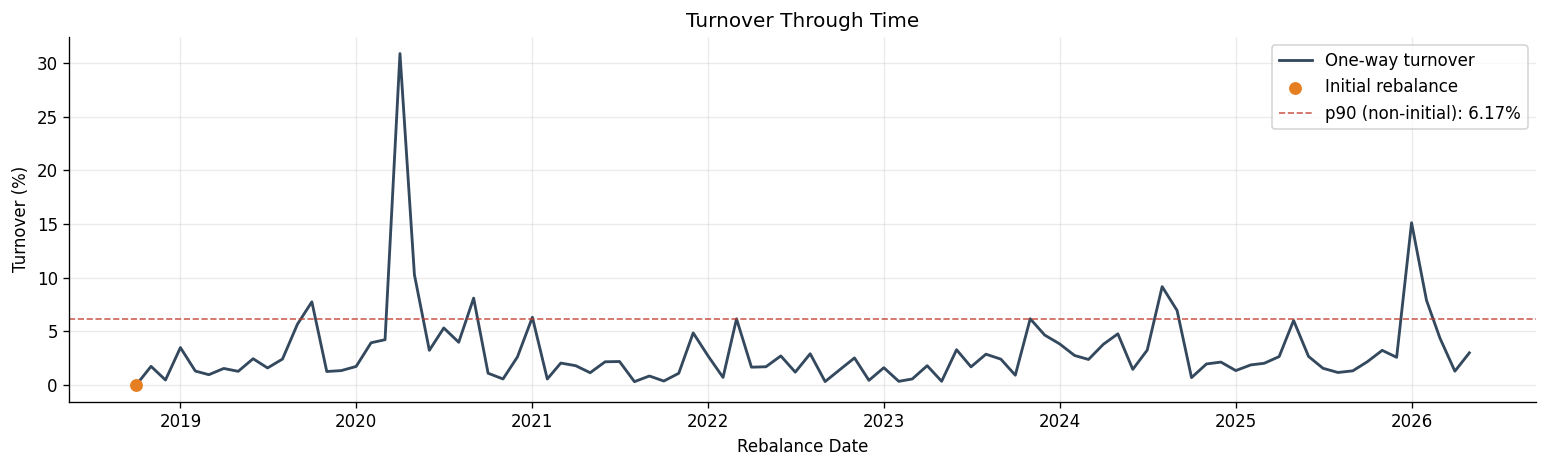

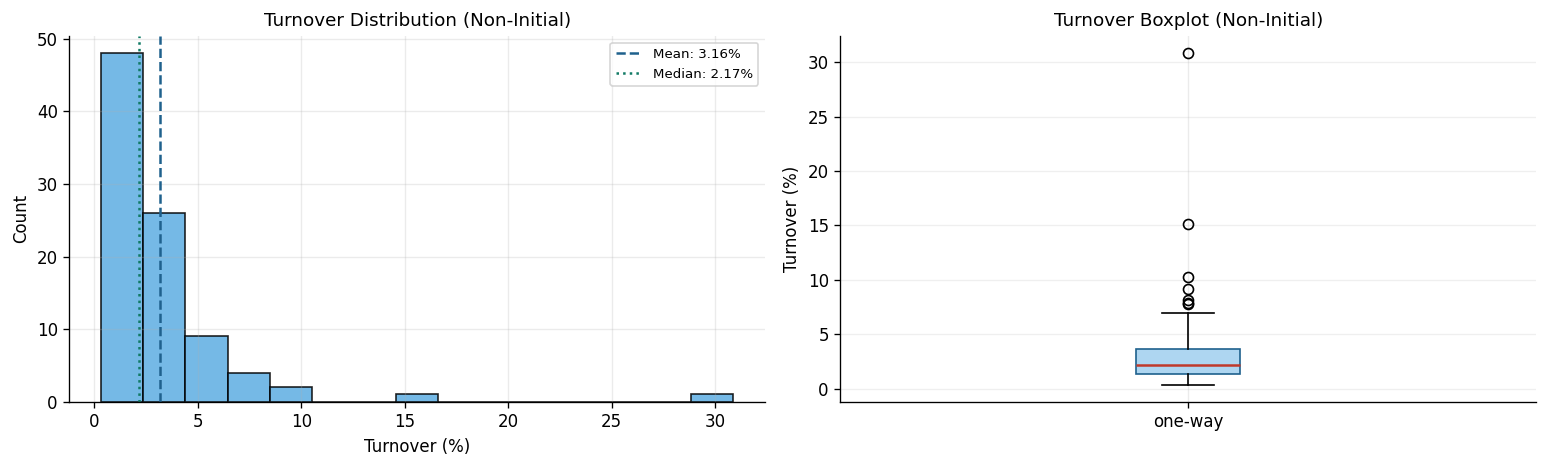

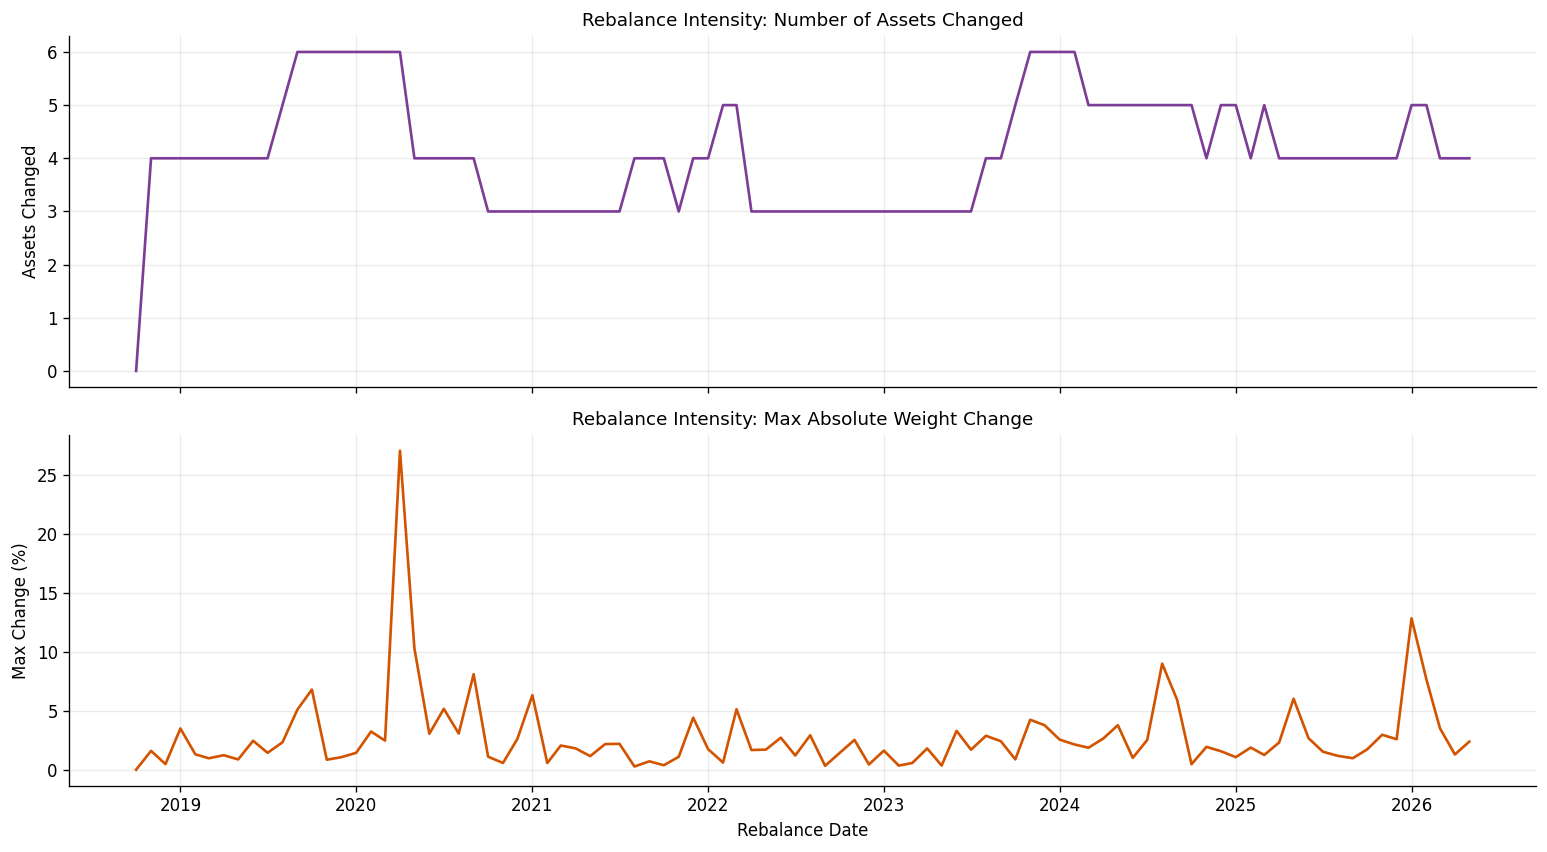

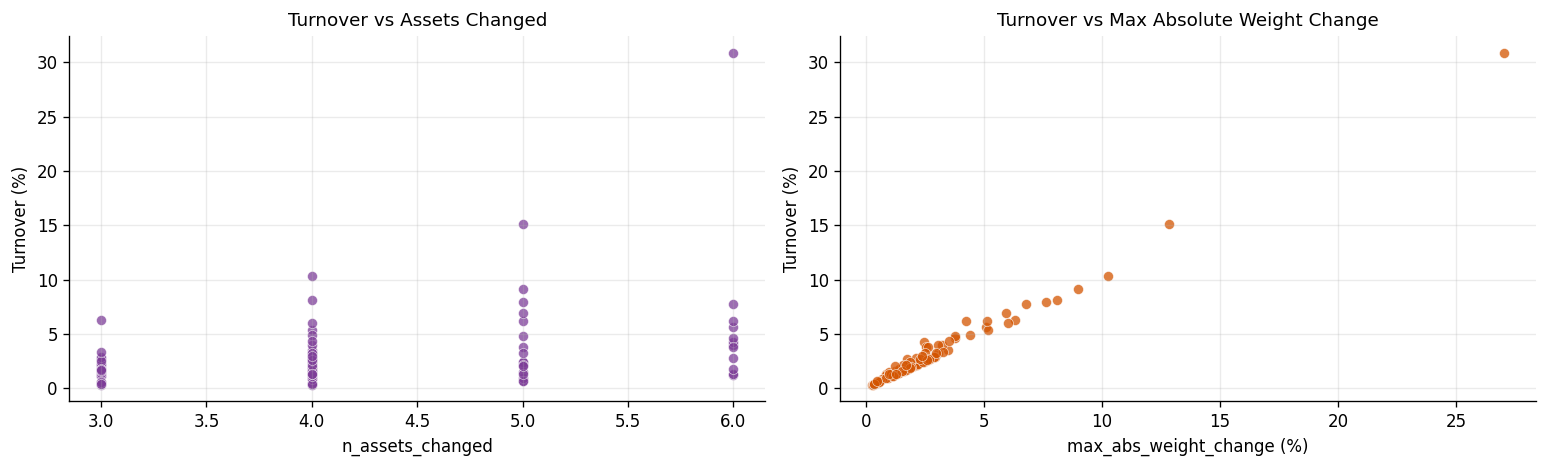

In [18]:
# ---- Section 6A-E: turnover and implementability diagnostics -----------------

t = turnover_history.copy().sort_index()

turnover_col = "turnover_one_way" if "turnover_one_way" in t.columns else None
if turnover_col is None:
    numeric_cols = t.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        turnover_col = numeric_cols[0]
        print(f"[Info] 'turnover_one_way' not found. Using '{turnover_col}' as turnover proxy.")
    else:
        raise ValueError("No numeric turnover column found in turnover_history.")

initial_col = "is_initial_rebalance" if "is_initial_rebalance" in t.columns else None
if initial_col is None:
    t["is_initial_rebalance"] = False
    initial_col = "is_initial_rebalance"
    print("[Info] 'is_initial_rebalance' not found. Treating all rows as non-initial.")

non_initial = ~t[initial_col].astype(bool)
t_eff = t.loc[non_initial].copy()

# A) Turnover summary table
summary_turnover = pd.DataFrame({
    "metric": [
        "total_rebalances",
        "non_initial_rebalances",
        "mean_turnover_non_initial",
        "median_turnover_non_initial",
        "max_turnover_non_initial",
        "mean_turnover_all",
    ],
    "value": [
        len(t),
        len(t_eff),
        t_eff[turnover_col].mean(),
        t_eff[turnover_col].median(),
        t_eff[turnover_col].max(),
        t[turnover_col].mean(),
    ]
})

turnover_percentiles = t_eff[turnover_col].quantile([0.75, 0.90, 0.95, 0.99]).rename("turnover")
turnover_tail_stats = pd.Series({
    "share_turnover_gt_5%": (t_eff[turnover_col] > 0.05).mean() * 100,
    "share_turnover_gt_10%": (t_eff[turnover_col] > 0.10).mean() * 100,
    "share_turnover_gt_20%": (t_eff[turnover_col] > 0.20).mean() * 100,
}).round(3)

summary_turnover_display = summary_turnover.copy()
summary_turnover_display["value_display"] = summary_turnover_display.apply(
    lambda r: f"{r['value']:.2%}" if "turnover" in r["metric"] else f"{int(r['value'])}",
    axis=1,
)

print("Turnover summary (non-initial emphasized):")
display(summary_turnover_display[["metric", "value_display"]].rename(columns={"value_display": "value"}))
print("Turnover percentiles (non-initial):")
display((turnover_percentiles * 100).round(3).to_frame("turnover_%"))
print("Turnover tail shares (non-initial):")
display(turnover_tail_stats.to_frame("value_%"))

# B) Time series of turnover
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t.index, t[turnover_col] * 100, color="#34495E", lw=1.7, label="One-way turnover")

if t[initial_col].any():
    t0 = t.loc[t[initial_col], turnover_col] * 100
    ax.scatter(t0.index, t0.values, color="#E67E22", s=45, zorder=3, label="Initial rebalance")

q90 = t_eff[turnover_col].quantile(0.90)
ax.axhline(q90 * 100, color="#C0392B", lw=1.0, ls="--", alpha=0.8,
           label=f"p90 (non-initial): {q90:.2%}")

ax.set_title("Turnover Through Time", fontsize=12)
ax.set_ylabel("Turnover (%)")
ax.set_xlabel("Rebalance Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# C) Turnover distribution (histogram + boxplot)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(t_eff[turnover_col] * 100, bins=15, color="#5DADE2", edgecolor="black", alpha=0.85)
axes[0].axvline(t_eff[turnover_col].mean() * 100, color="#1F618D", lw=1.5, ls="--",
                label=f"Mean: {t_eff[turnover_col].mean():.2%}")
axes[0].axvline(t_eff[turnover_col].median() * 100, color="#117A65", lw=1.5, ls=":",
                label=f"Median: {t_eff[turnover_col].median():.2%}")
axes[0].set_title("Turnover Distribution (Non-Initial)", fontsize=11)
axes[0].set_xlabel("Turnover (%)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=8)

axes[1].boxplot(t_eff[turnover_col] * 100, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", color="#1F618D"),
                medianprops=dict(color="#C0392B", linewidth=1.5))
axes[1].set_title("Turnover Boxplot (Non-Initial)", fontsize=11)
axes[1].set_ylabel("Turnover (%)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["one-way"])
axes[1].grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()

# D-E) Rebalance intensity and relation to allocation changes
has_n_changed = "n_assets_changed" in t.columns
has_max_abs = "max_abs_weight_change" in t.columns

if has_n_changed or has_max_abs:
    n_sub = (1 if has_n_changed else 0) + (1 if has_max_abs else 0)
    fig, axes = plt.subplots(n_sub, 1, figsize=(13, 3.6 * n_sub), sharex=True)
    if n_sub == 1:
        axes = [axes]

    k = 0
    if has_n_changed:
        ax = axes[k]
        ax.plot(t.index, t["n_assets_changed"], color="#7D3C98", lw=1.6)
        ax.set_title("Rebalance Intensity: Number of Assets Changed", fontsize=11)
        ax.set_ylabel("Assets Changed")
        ax.grid(alpha=0.25)
        k += 1

    if has_max_abs:
        ax = axes[k]
        ax.plot(t.index, t["max_abs_weight_change"] * 100, color="#D35400", lw=1.6)
        ax.set_title("Rebalance Intensity: Max Absolute Weight Change", fontsize=11)
        ax.set_ylabel("Max Change (%)")
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Rebalance Date")
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2 if (has_n_changed and has_max_abs) else 1, figsize=(13, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    j = 0
    if has_n_changed:
        ax = axes[j]
        ax.scatter(t_eff["n_assets_changed"], t_eff[turnover_col] * 100,
                   alpha=0.75, color="#7D3C98", edgecolor="white", linewidth=0.4)
        ax.set_title("Turnover vs Assets Changed", fontsize=11)
        ax.set_xlabel("n_assets_changed")
        ax.set_ylabel("Turnover (%)")
        ax.grid(alpha=0.25)
        j += 1

    if has_max_abs:
        ax = axes[j]
        ax.scatter(t_eff["max_abs_weight_change"] * 100, t_eff[turnover_col] * 100,
                   alpha=0.75, color="#D35400", edgecolor="white", linewidth=0.4)
        ax.set_title("Turnover vs Max Absolute Weight Change", fontsize=11)
        ax.set_xlabel("max_abs_weight_change (%)")
        ax.set_ylabel("Turnover (%)")
        ax.grid(alpha=0.25)

    fig.tight_layout()
    plt.show()
else:
    print("[Info] Intensity columns not available ('n_assets_changed', 'max_abs_weight_change').")

# Persist artifacts for interpretation cell
turnover_section_artifacts = {
    "turnover_col": turnover_col,
    "summary": summary_turnover,
    "percentiles": turnover_percentiles,
    "tail_stats": turnover_tail_stats,
    "non_initial_series": t_eff[turnover_col],
    "q90_non_initial": q90,
    "has_n_assets_changed": has_n_changed,
    "has_max_abs_weight_change": has_max_abs,
}

### Reading turnover

**Question.** Does the operational load look reasonable for periodic rebalancing — *gross of any transaction-cost assumption*?

**Evidence (non-initial rebalances).**
- Mean ~3.16%; median ~2.17%. Percentiles: p75 ≈ 3.65%, p90 ≈ 6.18%, p95 ≈ 8.0%, p99 ≈ 16.7%.
- Tail intensity: ~15% of rebalances above 5% turnover, ~3% above 10%, ~1% above 20%.
- Turnover spikes co-move with `max_abs_weight_change` more than with `n_assets_changed` — the engine adjusts a small number of positions strongly, rather than reshuffling everything.

**Interpretation.** The strategy looks *operationally plausible* in gross terms: the median rebalance is a small adjustment, the tail is concentrated and identifiable, and corner cases are visible rather than hidden.

**Inferential limit.** This is *not* a net-of-cost evaluation. Realistic implementation costs include explicit commissions, bid-ask spread, slippage, market impact (Kyle, 1985; Almgren & Chriss, 2000), and partial-fill execution — none of which are modelled here. The DeMiguel-Garlappi-Nogales-Uppal (2009) result is directly relevant: cost drag is roughly proportional to turnover, so any "alpha" close in magnitude to the cost rate × turnover is *not robust*. A first-pass net analysis is performed in Notebook 02.


---
## 7 — Discussion

### 7.1 What the evidence supports
- The walk-forward OOS baseline of constrained MV exhibits a markedly *defensive* profile relative to the higher-beta benchmarks: lower realised volatility, shallower drawdowns, and a Sharpe edge over 60/40 that is economically interpretable.
- The risk–return give-up is *quantified and intuitive*: the strategy systematically forgoes upside in expansionary regimes to compress left-tail severity. This is consistent with the textbook MV objective and with the regularising role of the constraints (Jagannathan & Ma, 2003).
- The internal dynamics of the portfolio — weights, concentration, cap activity, turnover — are *traceable*. The baseline is not a black box: every property reported above can be reproduced from the artefacts in `data/processed/`.

### 7.2 What the evidence does not yet support
- It does *not* establish statistical superiority of MV over benchmarks; the Sharpe gaps observed are within the magnitude that DeMiguel, Garlappi & Uppal (2009) show to be commonly indistinguishable from 1/N once estimation error is honestly modelled.
- It does *not* establish that the (very small) crypto contribution is *stable* under parameter changes — by construction, the activation diagnostic is conditional on the realised path.
- It does *not* deliver an economic verdict net of trading frictions; the turnover analysis is gross-only.

### 7.3 Open methodological questions
- *How sensitive* is the result to lookback (126 / 252 / 504), to the crypto cap (0% / 10% / 20% / 25%), and to monthly-vs-quarterly rebalancing?
- *How much* of the gross edge survives after a plausible cost wedge (10 / 25 / 50 bps)?
- *Does shrinkage* (Ledoit-Wolf) materially change the allocation, the stability of weights, or the realised performance?
- *Is any of the above inferentially distinguishable from zero* under a circular block bootstrap?

### 7.4 Implication for the next chapter
The correct next step is **not** to add modelling complexity (HRP, CVaR, regime conditioning, ML overlays). The correct next step is to *stress* the baseline along the four dimensions above — exactly the agenda of Notebook 02. Adding complexity before checking robustness would conflate "more flexible model" with "more credible result", which the literature consistently warns against (Michaud, 1989; Harvey, Liu & Zhu, 2016).


---
## 8 — Limitations

A compact, honest enumeration of what restricts the inferential reach of this notebook.

| Domain | Limitation | Implication |
|---|---|---|
| Costs | No explicit commissions / spread / slippage / impact. | Implementability is read in *gross* terms only. |
| Statistical inference | No bootstrap intervals, no subperiod significance tests, no formal stability tests. | Performance differentials are point estimates of a single path. |
| Estimator | Sample covariance only — exposed to estimation error (Ledoit & Wolf, 2003). | Sensitivity to the estimator is open; addressed in Ch. 2. |
| Risk view | Variance objective; no CVaR / ES / drawdown-aware objective. | Tail-risk is *measured* but not *targeted*. |
| Crypto activation | Strictly descriptive, conditional on realised path. | No causal interpretation of when or why crypto enters MV. |
| Concentration | HHI/ENB are *weight-space* diagnostics. | They do not equal *risk-space* concentration. |
| Microstructure | Crypto trades 24/7; traditional assets do not. | Comparability and execution realism are not modelled. |
| Regime | Single OOS realisation; no formal regime conditioning. | Stock–bond correlation events (e.g., 2022) are not separable. |

**Bottom line of limitations.** This notebook produces *strong descriptive evidence on a well-instrumented baseline* and *honest framing of what that evidence cannot prove*. It is a foundation, not a verdict.


---
## 9 — Next methodological step (handover to Chapter 2)

The next correct decision is *not* to enrich the model; it is to **stress the baseline**. Until the current results have been shown to survive plausible perturbations, additional complexity would risk fitting more parameters to the same single OOS path.

**Chapter 2 agenda (Notebook 02):**
1. **Lookback sensitivity** — 126 / 252 / 504 days, with same constraints.
2. **Crypto-cap sensitivity** — 0% / 10% / 20% / 25%, including the No-Crypto control.
3. **Rebalance-frequency sensitivity** — monthly vs quarterly, gross *and* net.
4. **Transaction-cost evaluation** — 0 / 10 / 25 / 50 bps applied to turnover.
5. **Estimator sensitivity** — sample vs Ledoit-Wolf shrinkage.
6. **Light confirmatory layer** — circular block bootstrap (Politis & Romano, 1994) on a *preregistered* set of Sharpe-difference comparisons.

**Sequencing rationale.** Only after this robustness layer does it make sense to add CVaR/ES objectives, HRP, regime conditioning, or ML overlays — each of which is a *separate research question* rather than a refinement of the current one.

**Scope of this notebook.** Notebook 01 *does not* implement the agenda above. Its role is to (i) deliver a clean, reproducible baseline, (ii) characterise it descriptively in OOS, and (iii) make explicit the inferential frontier that Chapter 2 must move.


---
## References

- Almgren, R., & Chriss, N. (2000). *Optimal execution of portfolio transactions.* Journal of Risk, 3(2).
- Ang, A., & Bekaert, G. (2002). *International asset allocation with regime shifts.* Review of Financial Studies, 15(4).
- Best, M. J., & Grauer, R. R. (1991). *On the sensitivity of mean-variance-efficient portfolios to changes in asset means.* Review of Financial Studies, 4(2).
- Bouchaud, J.-P., Potters, M., & Aguilar, J.-P. (1997). *Missing information and asset allocation.* Working paper.
- Chopra, V. K., & Ziemba, W. T. (1993). *The effect of errors in means, variances, and covariances on optimal portfolio choice.* Journal of Portfolio Management, 19(2).
- DeMiguel, V., Garlappi, L., & Uppal, R. (2009). *Optimal versus naive diversification: how inefficient is the 1/N portfolio strategy?* Review of Financial Studies, 22(5).
- DeMiguel, V., Garlappi, L., Nogales, F. J., & Uppal, R. (2009). *A generalized approach to portfolio optimization: improving performance by constraining portfolio norms.* Management Science, 55(5).
- Harvey, C. R., Liu, Y., & Zhu, H. (2016). *…and the cross-section of expected returns.* Review of Financial Studies, 29(1).
- Jagannathan, R., & Ma, T. (2003). *Risk reduction in large portfolios: why imposing the wrong constraints helps.* Journal of Finance, 58(4).
- Kyle, A. S. (1985). *Continuous auctions and insider trading.* Econometrica, 53(6).
- Ledoit, O., & Wolf, M. (2003). *Improved estimation of the covariance matrix of stock returns with an application to portfolio selection.* Journal of Empirical Finance, 10(5).
- Ledoit, O., & Wolf, M. (2004). *Honey, I shrunk the sample covariance matrix.* Journal of Portfolio Management, 30(4).
- Liu, Y., & Tsyvinski, A. (2021). *Risks and returns of cryptocurrency.* Review of Financial Studies, 34(6).
- Liu, Y., Tsyvinski, A., & Wu, X. (2022). *Common risk factors in cryptocurrency.* Journal of Finance, 77(2).
- Lo, A. W. (2002). *The statistics of Sharpe ratios.* Financial Analysts Journal, 58(4).
- Longin, F., & Solnik, B. (2001). *Extreme correlation of international equity markets.* Journal of Finance, 56(2).
- Markowitz, H. (1952). *Portfolio selection.* Journal of Finance, 7(1).
- Michaud, R. O. (1989). *The Markowitz optimization enigma: is "optimized" optimal?* Financial Analysts Journal, 45(1).
- Politis, D. N., & Romano, J. P. (1994). *The stationary bootstrap.* Journal of the American Statistical Association, 89(428).
